In [50]:
%pip install pandas numpy seaborn matplotlib scikit-learn

Defaulting to user installation because normal site-packages is not writeable
Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.3 -> 26.1
[notice] To update, run: python.exe -m pip install --upgrade pip


# Analysis of wicket distribution per over to see which overs contribute the most to Purple Cap

In [51]:
%matplotlib inline
import matplotlib.pyplot as plt
import numpy as np

from pathlib import Path

import pandas as pd
import seaborn as sns

from matplotlib.container import BarContainer
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.model_selection import train_test_split

In [52]:
BASE_DIR = Path.cwd()
OUTPUT_DIR = BASE_DIR / "analysis_outputs"

NA_VALUES = ["NA", "N/A", "na", "none", "None", "null", "NULL", ""]
NUMERIC_MATCH_COLUMNS = ["id", "target_runs", "target_overs", "result_margin"]
NUMERIC_DELIVERY_COLUMNS = [
    "match_id",
    "inning",
    "over",
    "ball",
    "batsman_runs",
    "extra_runs",
    "total_runs",
    "is_wicket",
]

# sns style guide
sns.set_theme(style="whitegrid", context="talk")

In [53]:
# utility function to clean object columns
def _clean_object_columns(df: pd.DataFrame) -> pd.DataFrame:
    """Strip whitespace and normalize common missing-value markers."""
    cleaned = df.copy()
    for column in cleaned.select_dtypes(include=["object", "string"]).columns:
        cleaned[column] = cleaned[column].astype("string").str.strip()
        cleaned[column] = cleaned[column].replace(NA_VALUES, pd.NA)
    return cleaned

# Loading both datasets and cleaning them

In [54]:
def load_and_clean_matches(path: str) -> pd.DataFrame:
    matches = pd.read_csv(path, na_values=NA_VALUES, keep_default_na=True)
    matches = matches.drop_duplicates().copy()
    matches = _clean_object_columns(matches)

    for column in NUMERIC_MATCH_COLUMNS:
        if column in matches.columns:
            matches[column] = pd.to_numeric(matches[column], errors="coerce")

    if "date" in matches.columns:
        matches["date"] = pd.to_datetime(matches["date"], errors="coerce", format="mixed")

    if "season" in matches.columns:
        matches["season"] = matches["season"].astype("string").str.strip()

    return matches


def load_and_clean_deliveries(path: str) -> pd.DataFrame:
    deliveries = pd.read_csv(path, na_values=NA_VALUES, keep_default_na=True)
    deliveries = deliveries.drop_duplicates().copy()
    deliveries = _clean_object_columns(deliveries)

    for column in NUMERIC_DELIVERY_COLUMNS:
        if column in deliveries.columns:
            deliveries[column] = pd.to_numeric(deliveries[column], errors="coerce")

    for column in ["over", "ball", "inning", "match_id", "is_wicket"]:
        if column in deliveries.columns:
            deliveries[column] = deliveries[column].fillna(0).astype(int)

    for column in ["batsman_runs", "extra_runs", "total_runs"]:
        if column in deliveries.columns:
            deliveries[column] = deliveries[column].fillna(0).astype(int)

    return deliveries


matches = load_and_clean_matches("assets/matches.csv")
deliveries = load_and_clean_deliveries("assets/deliveries.csv")

# Wicket analysis

Here, we analyze the wicket patterns by over for all the seasons and by season to construct our analysis heatmap and observe the wicket patterns.

In [55]:
def build_wicket_analysis(
    matches: pd.DataFrame, deliveries: pd.DataFrame
) -> tuple[pd.DataFrame, pd.DataFrame, pd.DataFrame, list[str]]:
    required_match_columns = {"id", "season", "date"}
    required_delivery_columns = {"match_id", "over", "is_wicket"}

    missing_match = required_match_columns.difference(matches.columns)
    missing_delivery = required_delivery_columns.difference(deliveries.columns)

    if missing_match:
        raise ValueError(
            f"matches.csv is missing required columns: {sorted(missing_match)}"
        )
    if missing_delivery:
        raise ValueError(
            f"deliveries.csv is missing required columns: {sorted(missing_delivery)}"
        )

    # constructing a merged dataset to make analysis easier
    merged = deliveries.merge(
        matches[["id", "season", "date"]],
        left_on="match_id",
        right_on="id",
        how="left",
        validate="many_to_one",
        suffixes=("", "_match"),
    )

    missing_season_rows = int(merged["season"].isna().sum())
    if missing_season_rows:
        raise ValueError(
            f"{missing_season_rows} deliveries could not be mapped to a season."
        )

    wicket_events = merged.loc[merged["is_wicket"].eq(1)].copy()
    wicket_events["over_number"] = wicket_events["over"] + 1

    max_over = int(wicket_events["over_number"].max())
    over_axis = list(range(1, max_over + 1))

    overall = (
        wicket_events.groupby("over_number", as_index=False)
        .size()
        .rename(columns={"size": "wickets"})
        .set_index("over_number")
        .reindex(over_axis, fill_value=0)
        .reset_index()
    )

    season_order = (
        matches.dropna(subset=["season", "date"])
        .sort_values(["date", "id"])
        .drop_duplicates(subset=["season"])["season"]
        .tolist()
    )
    if len(season_order) == 0:
        season_order = sorted(wicket_events["season"].dropna().unique().tolist())

    season_over = (
        wicket_events.groupby(["season", "over_number"], as_index=False)
        .size()
        .rename(columns={"size": "wickets"})
    )
    season_matrix = (
        season_over.pivot(index="season", columns="over_number", values="wickets")
        .reindex(index=season_order, columns=over_axis)
        .fillna(0)
        .astype(int)
    )

    top_over = overall.loc[overall["wickets"].idxmax()]
    top_over_number = top_over["over_number"].astype(int)
    top_over_wickets = top_over["wickets"].astype(int)
    summary_lines = [
        f"Total matches loaded: {len(matches):,}",
        f"Total deliveries loaded: {len(deliveries):,}",
        f"Total wicket events: {len(wicket_events):,}",
        f"Top wicket over overall: Over {top_over_number} with {top_over_wickets} wickets",
    ]

    return wicket_events, overall, season_matrix, summary_lines

# Utility functions to create and render plots inline

In [56]:
def plot_overall_wickets(overall: pd.DataFrame) -> None:
    fig, ax = plt.subplots(figsize=(14, 6))
    sns.barplot(data=overall, x="over_number", y="wickets", ax=ax, color="#5B8FF9")
    ax.set_title("Wickets by Over Across the Full IPL Dataset")
    ax.set_xlabel("Over number")
    ax.set_ylabel("Wickets")
    ax.set_xticks(range(len(overall)))
    ax.set_xticklabels(overall["over_number"])

    for container in ax.containers:
        if isinstance(container, BarContainer):
            ax.bar_label(container, fmt="%.0f", padding=2, fontsize=9)

    fig.tight_layout()
    plt.show()


def plot_season_heatmap(season_matrix: pd.DataFrame) -> None:
    height = max(6, 0.45 * len(season_matrix))
    fig, ax = plt.subplots(figsize=(16, height))
    sns.heatmap(
        season_matrix,
        ax=ax,
        cmap="YlOrRd",
        annot=True,
        fmt="d",
        linewidths=0.5,
        linecolor="white",
        cbar_kws={"label": "Wickets"},
    )
    ax.set_title("Wickets by Over and Season")
    ax.set_xlabel("Over number")
    ax.set_ylabel("Season")
    fig.tight_layout()
    plt.show()

# Main driver code

In [57]:
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

wicket_events, overall, season_matrix, summary_lines = build_wicket_analysis(
    matches, deliveries
)

overall_csv = OUTPUT_DIR / "wickets_by_over_overall.csv"
season_csv = OUTPUT_DIR / "wickets_by_over_season.csv"
overall.to_csv(overall_csv, index=False)
season_matrix.to_csv(season_csv)

In [58]:
overall

,over_number,wickets
0,1,463
1,2,503
2,3,533
3,4,548
4,5,576
5,6,540
6,7,444
7,8,472
8,9,537
9,10,498


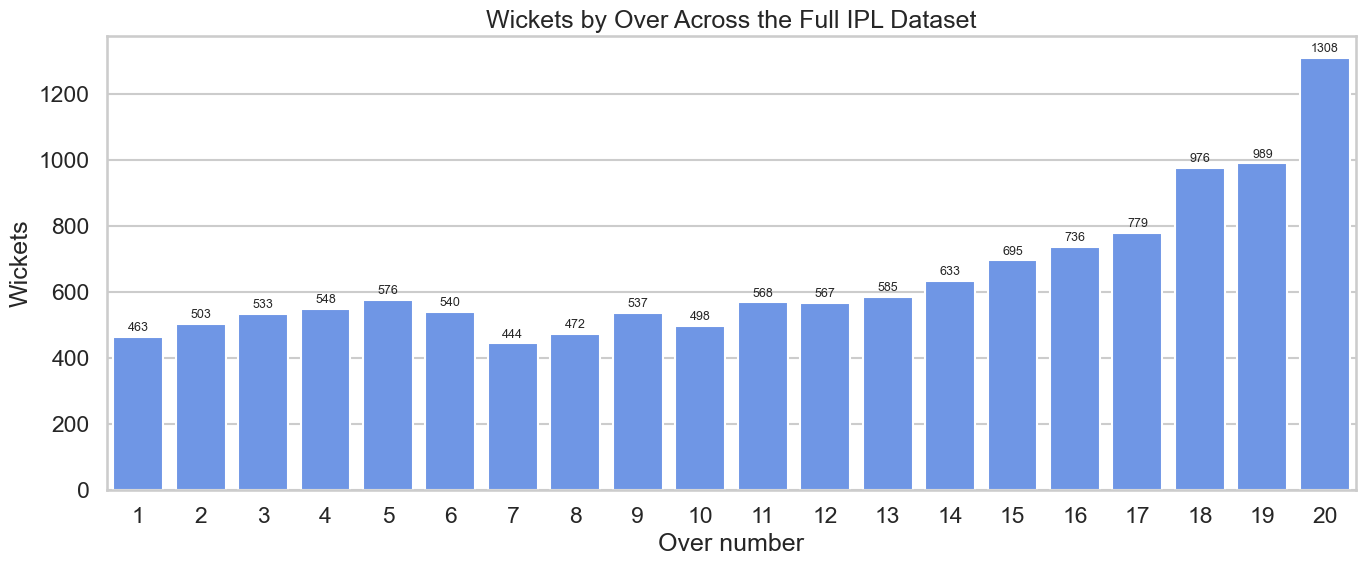

In [59]:
plot_overall_wickets(overall)

In [60]:
season_matrix

over_number,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17,18,19,20
season,,,,,,,,,,,,,,,,,,,,
2007/08,19,26,38,31,30,33,27,21,32,20,26,29,31,38,40,35,32,59,61,62
2009,39,33,26,26,31,33,30,17,27,33,30,26,27,30,36,44,43,47,44,76
2009/10,25,25,36,33,35,26,29,22,28,31,43,36,28,37,33,37,44,50,50,77
2011,24,35,33,44,35,39,24,30,34,30,43,26,39,33,48,48,46,56,67,79
2012,26,40,33,31,25,41,27,28,40,26,35,48,37,38,44,46,60,72,71,90
2013,34,37,44,32,40,30,33,55,29,34,37,35,42,41,34,57,59,78,68,93
2014,20,26,37,23,29,30,32,22,27,28,22,29,30,31,38,40,40,45,64,61
2015,27,14,26,24,46,38,22,24,34,28,29,27,23,35,40,30,45,51,61,67
2016,22,33,23,38,24,20,17,24,27,33,35,29,27,34,27,38,42,48,52,73


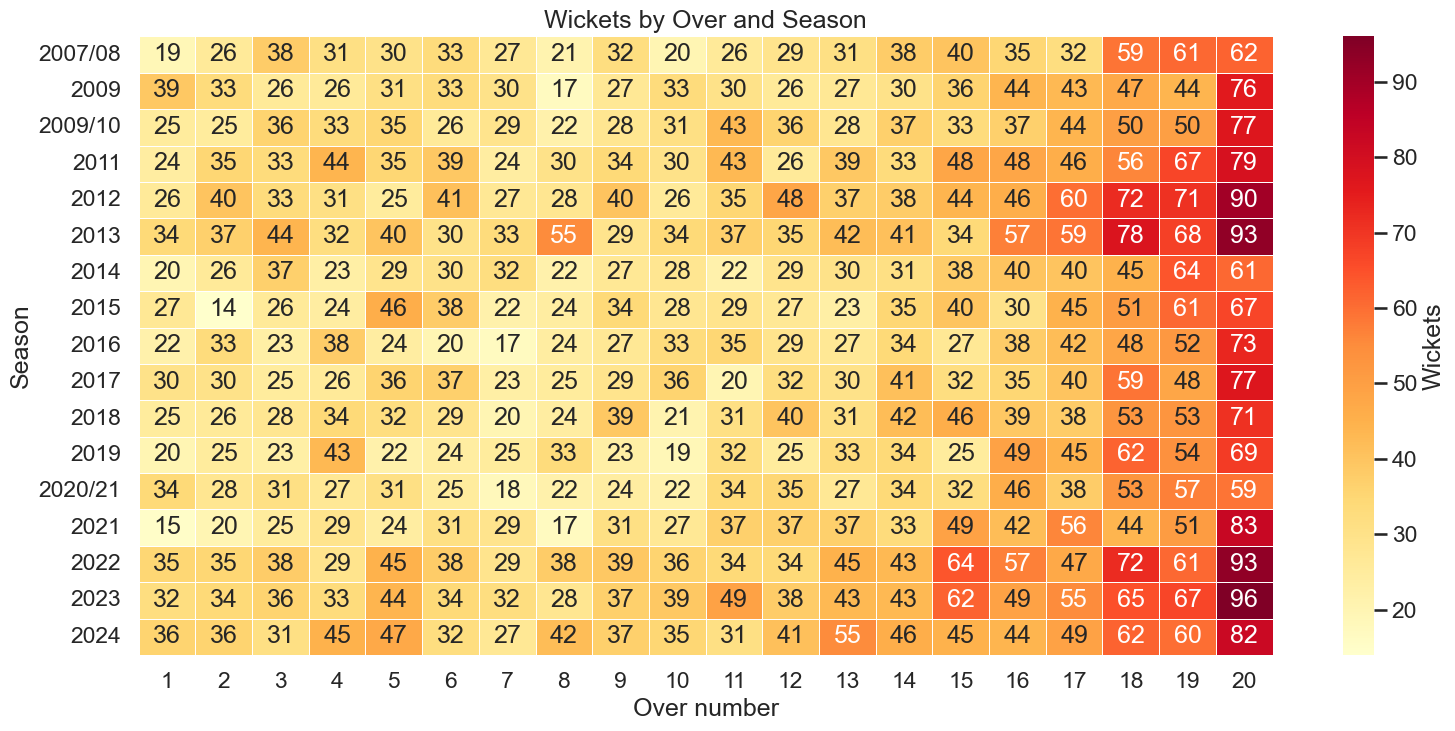

In [61]:
plot_season_heatmap(season_matrix)

## Linear Regression Model: Predicting Per-Over Wickets for 2025

In [74]:
matches_2025 = pd.read_csv('assets/matches_2025.csv', na_values=NA_VALUES, dtype={'season': str})
deliveries_2025 = pd.read_csv('assets/deliveries_2025.csv', na_values=NA_VALUES)

In [76]:
deliveries_2025['over_num'] = (deliveries_2025['over'].astype(int))

wicket_events_2025 = deliveries_2025[deliveries_2025['player_dismissed'].notna()]

wickets_by_over_2025 = wicket_events_2025.groupby('over_num').size().reset_index(name='wickets')
wickets_by_over_2025.columns = ['over', 'wickets']

# Ensure all overs 0-19 are represented (overs are 0-indexed in the data)
all_overs_2025 = pd.DataFrame({'over': range(0, 20)})
wickets_by_over_2025 = all_overs_2025.merge(wickets_by_over_2025, on='over', how='left').fillna(0)
wickets_by_over_2025['wickets'] = wickets_by_over_2025['wickets'].astype(int)
# Convert 0-indexed to 1-indexed for display
wickets_by_over_2025['over'] = wickets_by_over_2025['over'] + 1

wickets_by_over_2025

,over,wickets
0,1,34
1,2,36
2,3,40
3,4,35
4,5,41
5,6,27
6,7,37
7,8,45
8,9,27
9,10,32


In [73]:
# Check 2025 data quality
print("2025 Deliveries summary:")
print(f"Total deliveries: {len(deliveries_2025)}")
print(f"Date range: {deliveries_2025['date'].min()} to {deliveries_2025['date'].max()}")
print(f"Number of matches: {deliveries_2025['match_no'].nunique()}")
print(f"Total wickets recorded: {deliveries_2025['player_dismissed'].notna().sum()}")

print("\nWickets by type:")
wicket_type_counts = deliveries_2025[deliveries_2025['player_dismissed'].notna()]['wicket_type'].value_counts()
print(wicket_type_counts)

2025 Deliveries summary:
Total deliveries: 17183
Date range: Apr 01, 2025 to May 30, 2025
Number of matches: 73
Total wickets recorded: 872

Wickets by type:
wicket_type
caught          622
bowled          133
lbw              53
runout           39
stumped          18
hit wicket        3
retired out       2
retired hurt      2
Name: count, dtype: int64


In [70]:
# Build and evaluate a linear regression model for per-over wickets
training_rows = []
for season_index, season_name in enumerate(season_matrix.index):
    for over_number in season_matrix.columns:
        training_rows.append({
            'season_index': season_index,
            'over_number': int(over_number),
            'wickets': float(season_matrix.loc[season_name, over_number]),
        })

df_training = pd.DataFrame(training_rows)

# Features/target
X = df_training[['season_index', 'over_number']]
y = df_training['wickets']

# Use a random split to ensure non-empty test set
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

model = LinearRegression()
model.fit(X_train, y_train)

y_pred_train = model.predict(X_train)
y_pred_test = model.predict(X_test)

# Predict 2025 using the next season index after the historical seasons
season_index_2025 = len(season_matrix.index)
df_predictions_2025 = pd.DataFrame({
    'season_index': season_index_2025,
    'over_number': list(range(1, 21)),
})
df_predictions_2025['predicted_wickets'] = model.predict(df_predictions_2025[['season_index', 'over_number']])
df_predictions_2025['predicted_wickets'] = df_predictions_2025['predicted_wickets'].clip(lower=0)
df_predictions_2025['predicted_wickets_rounded'] = df_predictions_2025['predicted_wickets'].round(0).astype(int)

# Metrics
train_rmse = np.sqrt(mean_squared_error(y_train, y_pred_train))
train_mae = mean_absolute_error(y_train, y_pred_train)
train_r2 = r2_score(y_train, y_pred_train)

test_rmse = np.sqrt(mean_squared_error(y_test, y_pred_test))
test_mae = mean_absolute_error(y_test, y_pred_test)
test_r2 = r2_score(y_test, y_pred_test)

print('Linear regression model fitted successfully.')
print(f'Historical training rows: {len(df_training)}')
print(f'Training RMSE: {train_rmse:.4f}')
print(f'Training MAE: {train_mae:.4f}')
print(f'Training R²: {train_r2:.4f}')
print(f'Testing RMSE: {test_rmse:.4f}')
print(f'Testing MAE: {test_mae:.4f}')
print(f'Testing R²: {test_r2:.4f}')
print('\n2025 predictions:')
df_predictions_2025[['over_number', 'predicted_wickets', 'predicted_wickets_rounded']]

Linear regression model fitted successfully.
Historical training rows: 340
Training RMSE: 10.2365
Training MAE: 7.9767
Training R²: 0.4725
Testing RMSE: 11.6348
Testing MAE: 8.5149
Testing R²: 0.4733

2025 predictions:


,over_number,predicted_wickets,predicted_wickets_rounded
0,1,23.983029,24
1,2,25.660615,26
2,3,27.338200,27
3,4,29.015786,29
4,5,30.693372,31
5,6,32.370958,32
6,7,34.048544,34
7,8,35.726130,36
8,9,37.403716,37
9,10,39.081302,39
